# Participant-level encoders

Each participant is one training row: their per-question embeddings averaged
into a single vector. This is the baseline representation; notebook 02 runs
the same encoders without that averaging.

Three sentence-transformer checkpoints run as separate arms in one pass
(small/base/large, 384/768/1024 dims, all with a 512-token context), so
encoder capacity and input granularity form a declared grid rather than a
sequence of one-off swaps (PROTOCOL.md, Section 7).

**All reported metrics are on the held-out test participants**, who are
never trained on and are the same set in every arm. Cross-validation numbers
appear only where labelled, and reflect model selection on training data.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

from src import config, data, encoders, splits, logging_utils
from src.plotting import plot_confusion_matrix, BAND_LABELS, SCREENING_LABELS
from src.pipeline import TARGETS, build_train_frame, compute_frozen_embeddings, \
    arm_models, e5_arm, encoder_data, encoders_for, question_encoders_for, \
    run_encoder, search_label

## Run configuration

In [2]:
E5_MODELS = [
    "intfloat/multilingual-e5-small",   # 384 dims
    "intfloat/multilingual-e5-base",    # 768 dims
    "intfloat/multilingual-e5-large",   # 1024 dims
]

In [3]:
cfg = config.TrainingConfig(
    augmentation=config.AUGMENTATION_NONE,   # or config.AUGMENTATION_NONE  config.AUGMENTATION_LLM
    seeds=(42,),
    n_cv_splits=5,
    n_search_iter=0,      # 0 = sin busqueda; ver tune_model para afinar una familia
    beto_model="dccuchile/bert-base-spanish-wwm-cased",
    max_tokens=512,
    chunk_stride=256,
    tfidf_max_features=300,
    tfidf_ngram_range=(1, 2),
    tfidf_min_df=3,
    tfidf_max_df=0.90,
    tfidf_lemmatize=True,
    tfidf_normalize_numbers=True,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")
GRANULARITY = config.GRANULARITY_PARTICIPANT
ARMS = encoders_for(cfg, E5_MODELS)
ALL_ARMS = ARMS + question_encoders_for(cfg, E5_MODELS)
ARM_MODELS = arm_models(cfg, E5_MODELS)
print("arms:", ARMS)
cfg

device: cuda
arms: ['E0_TFIDF', 'E1_BETO', 'E2_E5SMALL', 'E2_E5BASE', 'E2_E5LARGE', 'E7_ROBERTA_MENTAL']


TrainingConfig(augmentation='no_augmentation', seeds=(42,), n_cv_splits=5, n_search_iter=0, beto_model='dccuchile/bert-base-spanish-wwm-cased', sentence_transformer_model='intfloat/multilingual-e5-small', mental_es_model='ELiRF/RoBERTa-es-mental-large', max_tokens=512, chunk_stride=256, tfidf_max_features=300, tfidf_ngram_range=(1, 2), tfidf_min_df=3, tfidf_max_df=0.9, tfidf_lemmatize=True, tfidf_normalize_numbers=True)

In [4]:
df = data.load_dataset()
train_ids, test_ids = splits.train_test_participants(df)
train_frame, groups = build_train_frame(df, train_ids, test_ids, cfg)
test_frame = df.loc[test_ids]
N_TEST = len(test_frame)
print(f"train: {len(train_frame)} rows, test: {N_TEST} held-out participants")

train: 110 rows, test: 48 held-out participants


In [5]:
run_dir = config.results_dir(cfg.augmentation, granularity=GRANULARITY)
combined = pd.concat([train_frame[config.QUESTIONS], test_frame[config.QUESTIONS]])

embeddings = compute_frozen_embeddings(combined, device, cfg, run_dir, e5_models=E5_MODELS)
docs_all = encoders.participant_documents(combined, cfg)
for name, matrix in embeddings.items():
    print(f"{name}: {matrix.shape}")

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 6591.17it/s]
[transformers] RobertaModel LOAD REPORT from: ELiRF/RoBERTa-es-mental-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (560 > 512). Running this sequence through the model will result in indexing errors


E1_BETO: (158, 768)
E2_E5SMALL: (158, 384)
E2_E5BASE: (158, 768)
E2_E5LARGE: (158, 1024)
E7_ROBERTA_MENTAL: (158, 1024)


In [6]:
def report_encoder(encoder_name, run_rows):
    runs = pd.DataFrame(run_rows)
    print(f"[TEST] {encoder_name}: metrics on the {N_TEST} held-out participants, per seed")
    display(runs.pivot(index="seed", columns="target", values=["rmse", "mae", "r2"]).round(3))

    # Filtered to this run's search regime: a defaults run and an earlier
    # tuned run of the same arm both live in the log, and pivoting over both
    # would collide on (model_name, seed).
    trials = logging_utils.load_trials(cfg.augmentation, granularity=GRANULARITY)
    trials = trials[(trials["encoder"] == encoder_name)
                    & (trials["search"] == search_label(cfg))]
    for target in TARGETS:
        print(f"[CROSS-VALIDATION on training data] RMSE per candidate regressor ({target}). "
              f"This is what model selection used; it is not a test score.")
        display(trials[trials["target"] == target].pivot(
            index="model_name", columns="seed", values="cv_rmse").round(3))

    fig, axes = plt.subplots(2, 2, figsize=(9, 8))
    for i, target in enumerate(TARGETS):
        target_runs = runs[runs["target"] == target]
        best_row = target_runs.loc[target_runs["rmse"].idxmin()]
        seed = int(best_row["seed"])
        plot_confusion_matrix(axes[i, 0], best_row["band_confusion_matrix"], BAND_LABELS,
                                f"{target} severity bands (seed={seed})")
        plot_confusion_matrix(axes[i, 1], best_row["screening_confusion_matrix"], SCREENING_LABELS,
                                f"{target} screening (seed={seed})")
    plt.suptitle(f"[TEST] {encoder_name}: confusion matrices, best seed per target")
    plt.tight_layout()
    plt.show()


def train_and_report(encoder_name):
    X_all, preprocessor = encoder_data(encoder_name, combined, docs_all, embeddings, cfg)
    X_train_enc = X_all.loc[train_frame.index]
    X_test_enc = X_all.loc[test_frame.index]
    t0 = time.time()
    run_rows = run_encoder(encoder_name, X_train_enc, X_test_enc, preprocessor,
                            train_frame, test_frame, groups, cfg, notebook="01",
                            encoder_model=ARM_MODELS[encoder_name])
    print(f"{encoder_name} done in {(time.time()-t0)/60:.1f} min")
    report_encoder(encoder_name, run_rows)

### Stage 1: TF-IDF

E0_TFIDF seed=42 target=PHQ9 best=RandomForest rmse=5.452 r2=0.015 (24.1s)
E0_TFIDF seed=42 target=GAD7 best=RandomForest rmse=4.916 r2=0.045 (24.2s)
E0_TFIDF done in 0.8 min
[TEST] E0_TFIDF: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.916  5.452  4.047  4.412  0.045  0.015

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.892
DecisionTree,8.057
ExtraTrees,5.813
GradientBoosting,5.950
KNN,6.260
LightGBM,5.873
RandomForest,5.797
Ridge,5.910
SVR,5.827


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.003
DecisionTree,6.102
ExtraTrees,4.804
GradientBoosting,5.071
KNN,5.083
LightGBM,5.197
RandomForest,4.766
Ridge,4.943
SVR,4.839


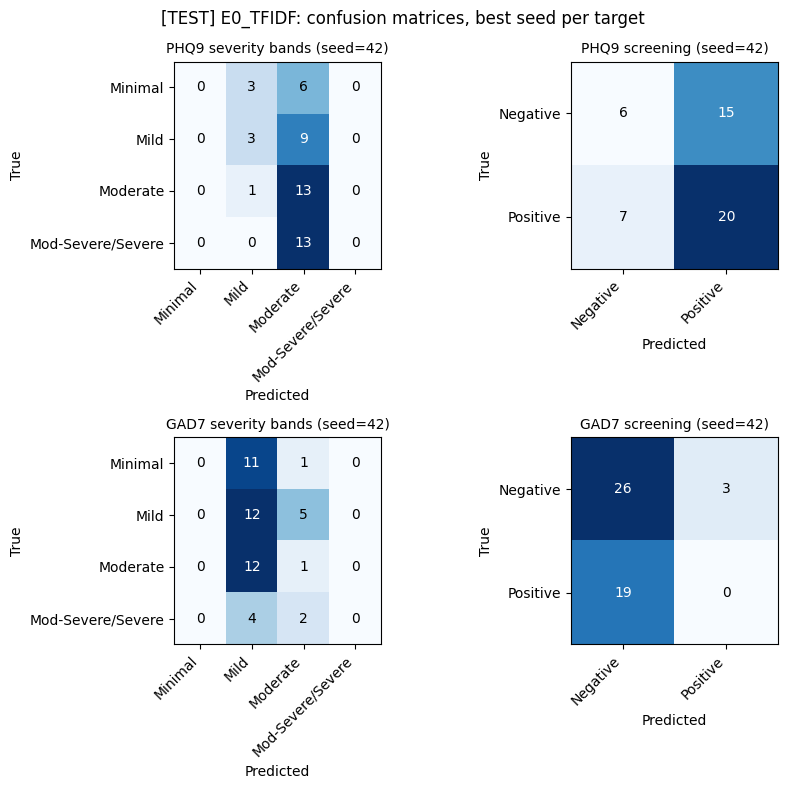

In [7]:
train_and_report("E0_TFIDF")

### Stage 2: BETO (frozen)

E1_BETO seed=42 target=PHQ9 best=SVR rmse=4.913 r2=0.201 (66.4s)
E1_BETO seed=42 target=GAD7 best=SVR rmse=4.456 r2=0.216 (70.8s)
E1_BETO done in 2.3 min
[TEST] E1_BETO: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.456  4.913  3.646  3.968  0.216  0.201

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.390
DecisionTree,7.096
ExtraTrees,5.539
GradientBoosting,5.567
KNN,5.610
LightGBM,6.167
RandomForest,5.534
Ridge,6.303
SVR,5.310


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.698
DecisionTree,6.027
ExtraTrees,4.614
GradientBoosting,4.828
KNN,4.739
LightGBM,5.249
RandomForest,4.616
Ridge,6.230
SVR,4.513


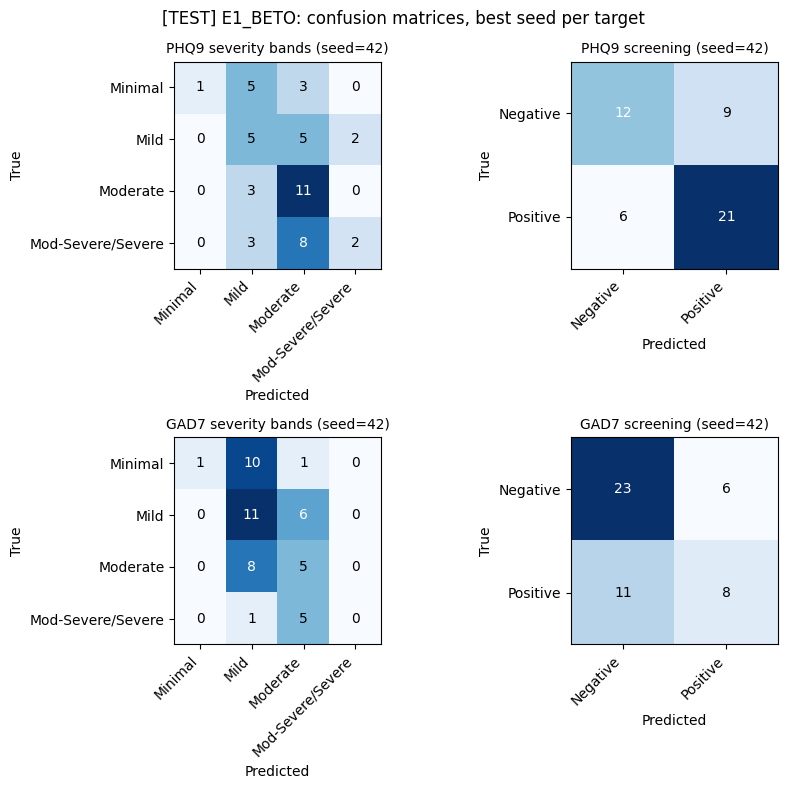

In [8]:
train_and_report("E1_BETO")

### Stage 3: e5-small (frozen)

E2_E5SMALL seed=42 target=PHQ9 best=AdaBoost rmse=4.830 r2=0.227 (37.2s)
E2_E5SMALL seed=42 target=GAD7 best=RandomForest rmse=4.563 r2=0.178 (21.1s)
E2_E5SMALL done in 1.0 min
[TEST] E2_E5SMALL: metrics on the 48 held-out participants, per seed


rmse          mae            r2       
target   GAD7  PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                           
42      4.563  4.83  3.756  3.912  0.178  0.227

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.517
DecisionTree,8.272
ExtraTrees,5.579
GradientBoosting,5.808
KNN,5.720
LightGBM,5.894
RandomForest,5.580
Ridge,6.838
SVR,5.569


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.576
DecisionTree,6.421
ExtraTrees,4.656
GradientBoosting,4.712
KNN,4.799
LightGBM,4.744
RandomForest,4.563
Ridge,5.624
SVR,4.564


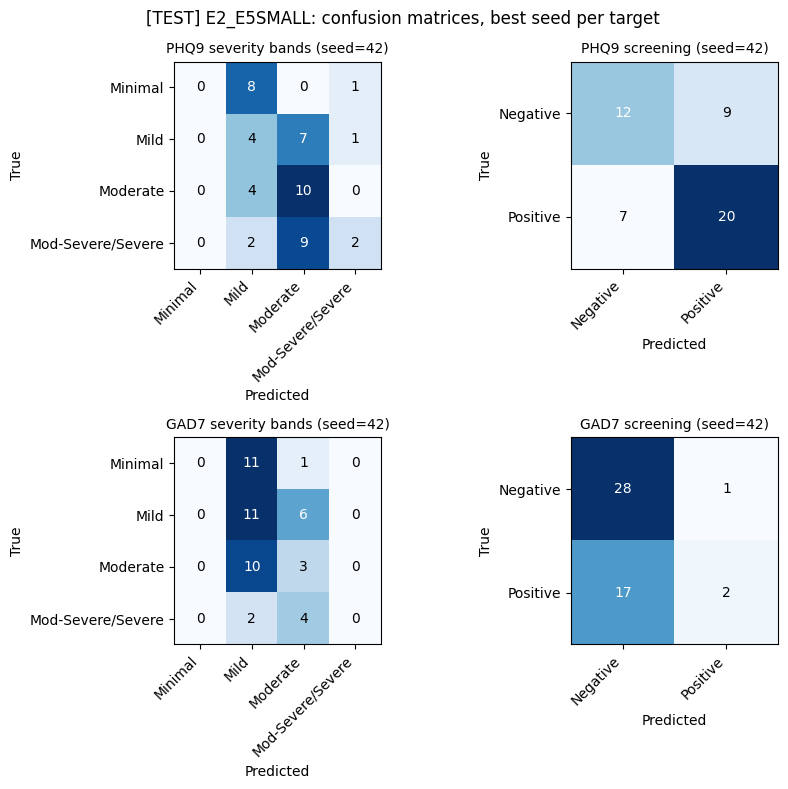

In [9]:
train_and_report(e5_arm(E5_MODELS[0], question_level=False))

### Stage 4: e5-base (frozen)

E2_E5BASE seed=42 target=PHQ9 best=AdaBoost rmse=4.871 r2=0.214 (56.9s)
E2_E5BASE seed=42 target=GAD7 best=SVR rmse=4.289 r2=0.273 (69.0s)
E2_E5BASE done in 2.1 min
[TEST] E2_E5BASE: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.289  4.871  3.367  4.045  0.273  0.214

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.154
DecisionTree,7.639
ExtraTrees,5.235
GradientBoosting,5.311
KNN,5.732
LightGBM,5.215
RandomForest,5.161
Ridge,6.212
SVR,5.158


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.536
DecisionTree,6.145
ExtraTrees,4.455
GradientBoosting,4.562
KNN,4.808
LightGBM,4.656
RandomForest,4.492
Ridge,5.059
SVR,4.373


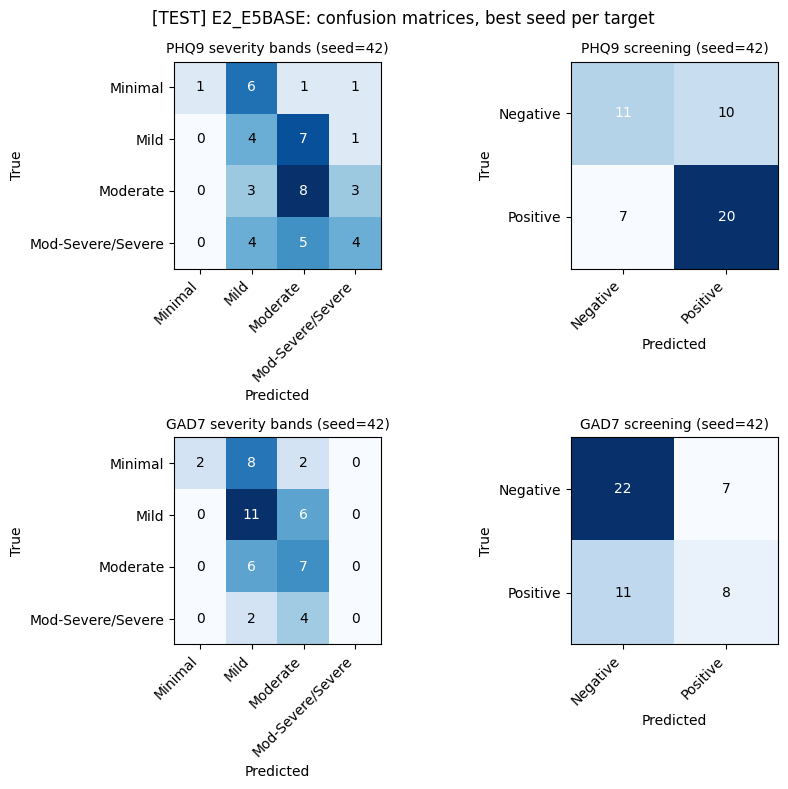

In [10]:
train_and_report(e5_arm(E5_MODELS[1], question_level=False))

### Stage 5: e5-large (frozen)

E2_E5LARGE seed=42 target=PHQ9 best=SVR rmse=4.703 r2=0.267 (86.4s)
E2_E5LARGE seed=42 target=GAD7 best=SVR rmse=4.187 r2=0.307 (84.5s)
E2_E5LARGE done in 2.8 min
[TEST] E2_E5LARGE: metrics on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.187  4.703  3.275  3.791  0.307  0.267

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.187
DecisionTree,7.155
ExtraTrees,5.160
GradientBoosting,5.365
KNN,5.458
LightGBM,5.601
RandomForest,5.146
Ridge,6.191
SVR,4.991


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.393
DecisionTree,6.164
ExtraTrees,4.326
GradientBoosting,4.579
KNN,4.641
LightGBM,4.538
RandomForest,4.330
Ridge,5.031
SVR,4.248


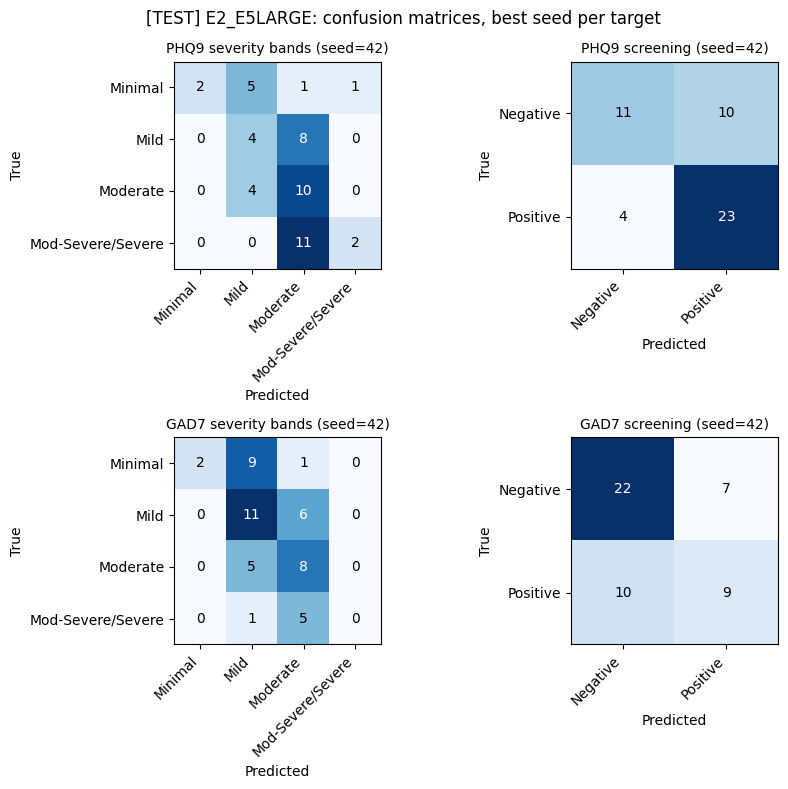

In [11]:
train_and_report(e5_arm(E5_MODELS[2], question_level=False))

### Stage 6: RoBERTa-es-mental (frozen)

`ELiRF/RoBERTa-es-mental-large`: `roberta-large-bne` continued with
masked-language-model pretraining on ~1.9M mental-health Reddit posts machine
translated into Spanish (ELiRF, UPV). It is a plain masked-language model, so
it is embedded exactly like BETO — mean pooling over the last hidden state,
no prefix, the same 512-token windows — and differs from `E1_BETO` in both the
backbone and the domain adaptation, since its own base checkpoint is no longer
published. The first run downloads ~1.4 GB.

E7_ROBERTA_MENTAL seed=42 target=PHQ9 best=SVR rmse=4.987 r2=0.176 (55.5s)
E7_ROBERTA_MENTAL seed=42 target=GAD7 best=SVR rmse=4.362 r2=0.248 (49.4s)
E7_ROBERTA_MENTAL done in 1.7 min
[TEST] E7_ROBERTA_MENTAL: metrics on the 48 held-out participants, per seed


rmse           mae           r2       
target   GAD7   PHQ9   GAD7  PHQ9   GAD7   PHQ9
seed                                           
42      4.362  4.987  3.413  4.07  0.248  0.176

[CROSS-VALIDATION on training data] RMSE per candidate regressor (PHQ9). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,5.386
DecisionTree,7.041
ExtraTrees,5.395
GradientBoosting,5.291
KNN,5.627
LightGBM,5.453
RandomForest,5.340
Ridge,5.828
SVR,5.219


[CROSS-VALIDATION on training data] RMSE per candidate regressor (GAD7). This is what model selection used; it is not a test score.


seed,42
model_name,
AdaBoost,4.326
DecisionTree,5.877
ExtraTrees,4.451
GradientBoosting,4.438
KNN,4.437
LightGBM,4.641
RandomForest,4.382
Ridge,4.946
SVR,4.307


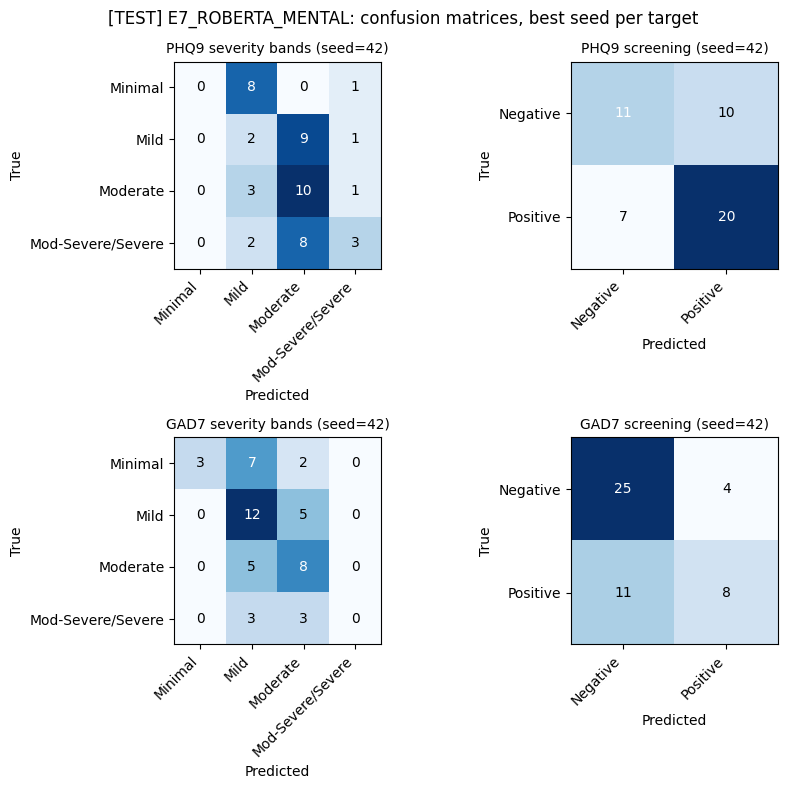

In [12]:
train_and_report("E7_ROBERTA_MENTAL")

### Summary

Every arm scored on the same held-out participants, so rows compare directly.

In [13]:
log = logging_utils.load_all_runs()
log = log[log.augmentation == cfg.augmentation]
# `search` is part of the grouping: the same arm can appear both with and
# without hyperparameter search, and averaging across the two would pool
# results from different procedures into one meaningless number.
summary = log.groupby(["encoder", "search", "target"])[
    ["rmse", "mae", "r2"]].agg(["mean", "std"]).round(3)
present = set(summary.index.get_level_values("encoder"))
# Restricted to this notebook's own arms. The named-feature arms
# (E10-E15) are logged under their own family and were fitted with a
# narrower set of candidate regressors, so listing them here would
# rank runs produced by different selection procedures.
DENSE_ARMS = [e for e in ALL_ARMS if not e.startswith(("E10_", "E11_",
               "E12_", "E13_", "E14_", "E15_"))]
order = [e for e in DENSE_ARMS if e in present]

spread = (f"mean and SD across {len(cfg.seeds)} seeds" if len(cfg.seeds) > 1
          else f"single seed ({cfg.seeds[0]}), so the SD columns are empty")
print(f"[TEST] {spread}, on the {N_TEST} held-out participants.")
print("RMSE and MAE in PHQ-9 / GAD-7 points (lower is better); R2 is the fraction of")
print("variance explained (0 = no better than predicting the training mean, negative = worse).")
display(summary.loc[order])

[TEST] single seed (42), so the SD columns are empty, on the 48 held-out participants.
RMSE and MAE in PHQ-9 / GAD-7 points (lower is better); R2 is the fraction of
variance explained (0 = no better than predicting the training mean, negative = worse).


rmse        mae         r2    
                                      mean std   mean std   mean std
encoder             search   target                                 
E0_TFIDF            defaults GAD7    4.916 NaN  4.047 NaN  0.045 NaN
                             PHQ9    5.452 NaN  4.412 NaN  0.015 NaN
E1_BETO             defaults GAD7    4.456 NaN  3.646 NaN  0.216 NaN
                             PHQ9    4.913 NaN  3.968 NaN  0.201 NaN
E2_E5SMALL          defaults GAD7    4.563 NaN  3.756 NaN  0.178 NaN
                             PHQ9    4.830 NaN  3.912 NaN  0.227 NaN
E2_E5BASE           defaults GAD7    4.289 NaN  3.367 NaN  0.273 NaN
                             PHQ9    4.871 NaN  4.045 NaN  0.214 NaN
E2_E5LARGE          defaults GAD7    4.187 NaN  3.275 NaN  0.307 NaN
                             PHQ9    4.703 NaN  3.791 NaN  0.267 NaN
E7_ROBERTA_MENTAL   defaults GAD7    4.362 NaN  3.413 NaN  0.248 NaN
                             PHQ9    4.987 NaN  4.070 NaN  0.176 NaN
E0_TFIDF_QUESTION   defaults GAD7    4.828 NaN  3.978 NaN  0.079 NaN
                             PHQ9    5.292 NaN  4.301 NaN  0.073 NaN
E1_BETO_QUESTION    defaults GAD7    4.559 NaN  3.720 NaN  0.179 NaN
                             PHQ9    5.005 NaN  4.111 NaN  0.170 NaN
E2_E5SMALL_QUESTION defaults GAD7    4.490 NaN  3.675 NaN  0.204 NaN
                             PHQ9    4.916 NaN  4.044 NaN  0.200 NaN
E2_E5BASE_QUESTION  defaults GAD7    4.376 NaN  3.522 NaN  0.243 NaN
                             PHQ9    4.788 NaN  3.956 NaN  0.241 NaN
E2_E5LARGE_QUESTION defaults GAD7    4.541 NaN  3.686 NaN  0.186 NaN
                             PHQ9    4.634 NaN  3.826 NaN  0.289 NaN